Вам необходимо доделать задание с семинара, которое заключается в решении задачи классификации на датасете mnist. Задание нужно сдать в виде Jupyter Notebook с запускаемым кодом, которым можно воспроизвести лучшую модель.

Подробное описание задания:

1.   Скачайте датасет mnist

2.   Напишите модель, подобную модели с первой части семинара.

3.   Выведите summary модели.

4.   Обучите модель, добавив коллбек построения графиков обучения, напишите выводы: сошлась ли модель по итогам обучения.

5.   Сравните несколько архитектур, в том числе с различным количеством слоёв и подберите оптимальную. Обязательно используйте dropout и batchnorm и поясните свои выводы. Также можно попробовать различные активации в скрытых слоях.

6.   В конце напишите выводы и отчет о рассмотренных моделях. Отчёт должен быть в виде таблички, в которой описан номер эксперимента, минимальная ошибка на валидации, 4 классификационные метрики на тесте: аccuracy, precision, recall и f1-score, к отчету должно прилагаться описание. Выводы ожидаются в свободной форме и должны содержать информацию о том, почему, по вашему мнению, именно эта архитектура из рассмотренных получила наилучший скор на тесте.

Ссылки на туториалы с документацией и начало решения есть в тетрадке, приложенной к уроку.

In [ ]:
# 1. Скачайте датасет mnist

from torchvision import datasets

mnist = datasets.MNIST(root='mnist', download=True)

mnist

Dataset MNIST
    Number of datapoints: 60000
    Root location: mnist
    Split: Train

In [ ]:
# Посмотрим на данные

mnist[0]

# Это объект изображения из библиотеки PIL (Pillow).
# Mode=L - изображение градации серого (Luminance), а не цветное (RGB).
# Size=28x28 - маленькое изображение размером 28 на 28 пикселей.
# 5 - это метка, на картинке нарисована цифра пять.

(<PIL.Image.Image image mode=L size=28x28>, 5)

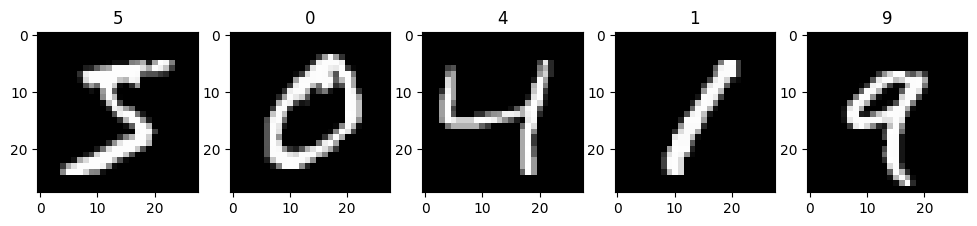

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12,5))

for i in range(5):
    x, y = mnist[i]
    plt.subplot(2, 5, i + 1)
    plt.title(f'{y}')
    plt.imshow(x, cmap='gray')

plt.show()

In [ ]:
# 2. Напишите модель, подобную модели с первой части семинара.

import torch
from torch import nn


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# у нас на входе картинка 28x28 = 784 пикселя. их нужно преобразовать в вектор из 784 чисел.
model = nn.Sequential(
    nn.Flatten(),  # Превращаем 28x28 в вектор из 784 чисел
    nn.Linear(784, 128),  # Первый слой: 784 входа, следовательно 128 нейронов
    nn.ReLU(),
    nn.Linear(128, 64),   # Второй слой: 128 входа, следовательно 64 нейрона
    nn.ReLU(),
    nn.Linear(64, 10),    # Выходной слой: 64 входа, следовательно 10 цифр
).to(device)

In [ ]:
# 3. Выведите summary модели.
from torchsummary import summary

# input_size=(1, 28, 28) - для черно-белого изображения
summary(model, input_size=(1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                  [-1, 128]         100,480
              ReLU-3                  [-1, 128]               0
            Linear-4                   [-1, 64]           8,256
              ReLU-5                   [-1, 64]               0
            Linear-6                   [-1, 10]             650
Total params: 109,386
Trainable params: 109,386
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.42
Estimated Total Size (MB): 0.43
----------------------------------------------------------------


In [ ]:
# 4. Обучите модель, добавив коллбек построения графиков обучения, напишите выводы: сошлась ли модель по итогам обучения.

from torch.utils.data import DataLoader, TensorDataset, random_split
import torch.optim as optim
import numpy as np
from IPython.display import clear_output
import matplotlib.pyplot as plt


mnist_train_full = datasets.MNIST(root='mnist', train=True, download=False)
mnist_test = datasets.MNIST(root='mnist', train=False, download=False)

In [ ]:
# Преобразуем изображения в векторы, 784 признака, и нормализуем
X_train_full = mnist_train_full.data.numpy().reshape(-1, 28*28) / 255.0
X_test = mnist_test.data.numpy().reshape(-1, 28*28) / 255.0
y_train_full = mnist_train_full.targets.numpy()
y_test = mnist_test.targets.numpy()

# в тензоры
X_train_full = torch.from_numpy(X_train_full).float().to(device)
y_train_full = torch.from_numpy(y_train_full).long().to(device)
X_test = torch.from_numpy(X_test).float().to(device)
y_test = torch.from_numpy(y_test).long().to(device)

full_dataset = TensorDataset(X_train_full, y_train_full)
train_size = int(0.8 * len(full_dataset))  # 80% на train
val_size = len(full_dataset) - train_size  # 20% на validation

# Разделяем случайным образом
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

test_dataset = TensorDataset(X_test, y_test)

BATCH_SIZE = 100

# Создаем загрузчики для всех трех выборок
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Размер батча: {BATCH_SIZE}")
print(f"Обучающих примеров: {len(train_dataset)}")
print(f"Валидационных примеров: {len(val_dataset)}")
print(f"Тестовых примеров: {len(test_dataset)}")
print(f"Форма входных данных: {X_train_full.shape}")

Размер батча: 100
Обучающих примеров: 48000
Валидационных примеров: 12000
Тестовых примеров: 10000
Форма входных данных: torch.Size([60000, 784])


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Функция для одной эпохи с precision, recall, f1
def run(model, dataloader, loss_function, optimizer=None):
    if optimizer == None:
        model.eval()
    else:
        model.train()

    total_loss = 0
    all_predicted = []
    all_labels = []

    with torch.set_grad_enabled(optimizer is not None):
        for X, y in dataloader:
            pred = model(X)
            loss = loss_function(pred, y)
            total_loss += loss.item()

            predicted = torch.argmax(pred, dim=1)

            # Сохраняем для метрик
            all_predicted.extend(predicted.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

            if optimizer != None:
                loss.backward()
                optimizer.step()
                optimizer.zero_grad()

    # Вычисляем все метрики
    accuracy = 100 * (np.array(all_predicted) == np.array(all_labels)).mean()
    precision = precision_score(all_labels, all_predicted, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_predicted, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_predicted, average='weighted', zero_division=0)

    avg_loss = total_loss / len(dataloader)

    return avg_loss, accuracy, precision, recall, f1

In [ ]:
# Функция для построения графиков
def show_losses(train_loss_hist, val_loss_hist,
                train_acc_hist, val_acc_hist,
                train_precision_hist, val_precision_hist,
                train_recall_hist, val_recall_hist,
                train_f1_hist, val_f1_hist):

    # Создаем 2x2 = 4 графика
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    (ax1, ax2), (ax3, ax4) = axes

    # График 1: Loss
    ax1.set_title('Loss')
    ax1.plot(np.arange(len(train_loss_hist)), train_loss_hist, label='Train Loss', color='blue')
    ax1.plot(np.arange(len(val_loss_hist)), val_loss_hist, label='Validation Loss', color='red')
    ax1.grid(True)
    ax1.legend()

    # График 2: Accuracy
    ax2.set_title('Accuracy (%)')
    ax2.plot(np.arange(len(train_acc_hist)), train_acc_hist, label='Train Accuracy', color='blue')
    ax2.plot(np.arange(len(val_acc_hist)), val_acc_hist, label='Validation Accuracy', color='red')
    ax2.grid(True)
    ax2.legend()
    ax2.set_ylim([0, 100])

    # График 3: Train Metrics (Precision, Recall, F1)
    ax3.set_title('Train Metrics')
    ax3.plot(np.arange(len(train_precision_hist)), train_precision_hist,
                label='Precision', color='green', linestyle='--')
    ax3.plot(np.arange(len(train_recall_hist)), train_recall_hist,
                label='Recall', color='orange', linestyle='--')
    ax3.plot(np.arange(len(train_f1_hist)), train_f1_hist,
                label='F1-Score', color='purple', linewidth=2)
    ax3.grid(True)
    ax3.legend()
    ax3.set_ylim([0, 1])

    # График 4: Validation Metrics (Precision, Recall, F1) - раньше был Test
    ax4.set_title('Validation Metrics')
    ax4.plot(np.arange(len(val_precision_hist)), val_precision_hist,
                label='Precision', color='green', linestyle='--')
    ax4.plot(np.arange(len(val_recall_hist)), val_recall_hist,
                label='Recall', color='orange', linestyle='--')
    ax4.plot(np.arange(len(val_f1_hist)), val_f1_hist,
                label='F1-Score', color='purple', linewidth=2)
    ax4.grid(True)
    ax4.legend()
    ax4.set_ylim([0, 1])

    plt.suptitle(f'Обучение модели (эпоха {len(train_loss_hist)})', fontsize=14)
    plt.tight_layout()
    plt.show()

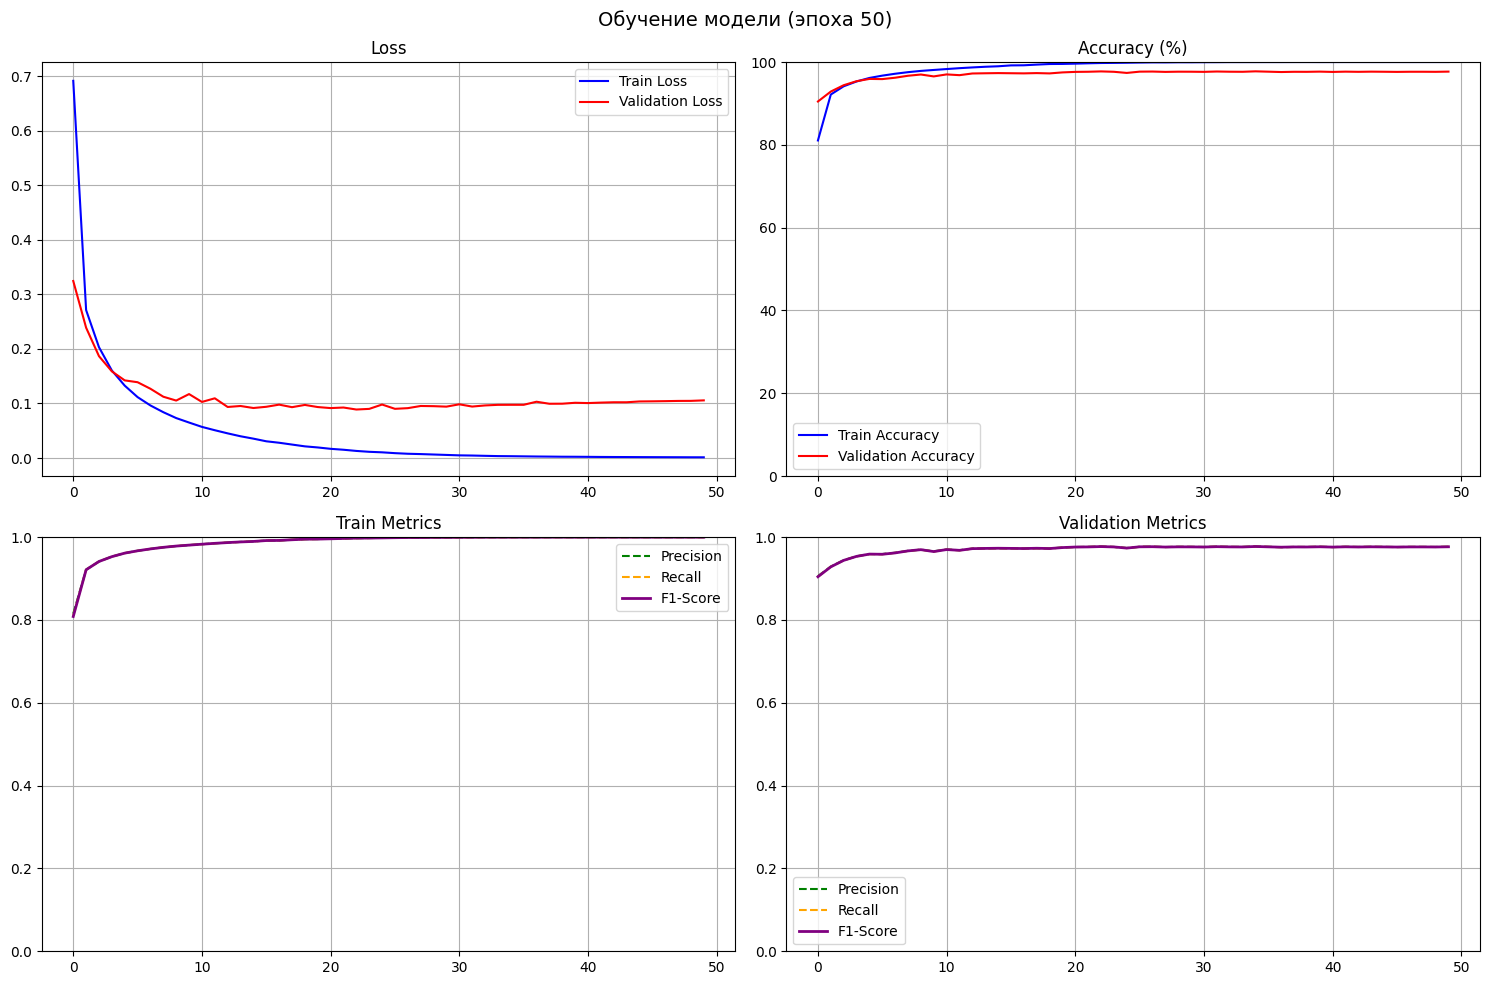

Epoch 50/50
Train - Loss: 0.0014, Acc: 100.00%, Precision: 1.000, Recall: 1.000, F1: 1.000
Val   - Loss: 0.1057, Acc: 97.68%, Precision: 0.977, Recall: 0.977, F1: 0.977

Загружена лучшая модель с валидационной ошибкой 0.0889 (эпоха 23)
Финальная оценка на тесте:
Test - Loss: 0.0957, Acc: 97.89%, Precision: 0.979, Recall: 0.979, F1: 0.979


{'train_loss_hist': [0.6911258980631828,
  0.2710979001286129,
  0.20304549772602817,
  0.16039938382649174,
  0.13266323262747998,
  0.1116338507233498,
  0.09632846517488361,
  0.08400457183403584,
  0.07323702536911393,
  0.06504454970515022,
  0.057093036950876315,
  0.050969355706668766,
  0.0452145246968333,
  0.03989653313668289,
  0.03552714447384157,
  0.030691003853280562,
  0.028026798565406352,
  0.024708609012304806,
  0.021419845926963412,
  0.019405982427997515,
  0.016900425728817937,
  0.015205624438385712,
  0.013037419235721852,
  0.011433572259556967,
  0.010475027398206294,
  0.008964000771326634,
  0.0078588565615064,
  0.007249690955965586,
  0.006475120477989549,
  0.005703627059968615,
  0.004926330082162167,
  0.004598669572502937,
  0.004060402937830077,
  0.0035671887802285105,
  0.0033786367794164107,
  0.0031046720749751937,
  0.0028264885248669696,
  0.002641261458605489,
  0.0024133900629749404,
  0.0023440309431559097,
  0.00219189334575276,
  0.0020054

In [ ]:
# Определяем функцию потерь и оптимизатор
loss_function = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

def train_model_function(model, model_name=""):
    epochs = 50
    train_loss_hist = []
    val_loss_hist = []
    train_acc_hist = []
    val_acc_hist = []
    train_precision_hist = []
    val_precision_hist = []
    train_recall_hist = []
    val_recall_hist = []
    train_f1_hist = []
    val_f1_hist = []

    min_val_loss = float('inf')
    min_val_loss_epoch = 0

    best_model_state = None

    for i in range(epochs):
        # Обучаем на train
        train_loss, train_acc, train_precision, train_recall, train_f1 = run(
            model, train_loader, loss_function, optimizer
        )
        train_loss_hist.append(train_loss)
        train_acc_hist.append(train_acc)
        train_precision_hist.append(train_precision)
        train_recall_hist.append(train_recall)
        train_f1_hist.append(train_f1)

        val_loss, val_acc, val_precision, val_recall, val_f1 = run(
            model, val_loader, loss_function
        )
        val_loss_hist.append(val_loss)
        val_acc_hist.append(val_acc)
        val_precision_hist.append(val_precision)
        val_recall_hist.append(val_recall)
        val_f1_hist.append(val_f1)

        if val_loss < min_val_loss:
            min_val_loss = val_loss
            min_val_loss_epoch = i + 1
            best_model_state = model.state_dict().copy()  # Сохраняем лучшую модель

        if i == epochs - 1:
            show_losses(train_loss_hist, val_loss_hist,
                      train_acc_hist, val_acc_hist,
                      train_precision_hist, val_precision_hist,
                      train_recall_hist, val_recall_hist,
                      train_f1_hist, val_f1_hist)

            print(f'Epoch {i+1}/{epochs}')
            print(f'Train - Loss: {train_loss:.4f}, Acc: {train_acc:.2f}%, '
                  f'Precision: {train_precision:.3f}, Recall: {train_recall:.3f}, F1: {train_f1:.3f}')
            print(f'Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%, '
                  f'Precision: {val_precision:.3f}, Recall: {val_recall:.3f}, F1: {val_f1:.3f}')

    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"\nЗагружена лучшая модель с валидационной ошибкой {min_val_loss:.4f} (эпоха {min_val_loss_epoch})")

        # Финальная оценка на тестовой выборке
        test_loss, test_acc, test_precision, test_recall, test_f1 = run(
            model, test_loader, loss_function
        )
        print(f"Финальная оценка на тесте:")
        print(f"Test - Loss: {test_loss:.4f}, Acc: {test_acc:.2f}%, "
              f"Precision: {test_precision:.3f}, Recall: {test_recall:.3f}, F1: {test_f1:.3f}")
    else:
        # Если не сохраняли (на всякий случай)
        test_loss, test_acc, test_precision, test_recall, test_f1 = run(
            model, test_loader, loss_function
        )

    return {
        'train_loss_hist': train_loss_hist,
        'val_loss_hist': val_loss_hist,
        'train_acc_hist': train_acc_hist,
        'val_acc_hist': val_acc_hist,
        'train_precision_hist': train_precision_hist,
        'val_precision_hist': val_precision_hist,
        'train_recall_hist': train_recall_hist,
        'val_recall_hist': val_recall_hist,
        'train_f1_hist': train_f1_hist,
        'val_f1_hist': val_f1_hist,

        'final_test_acc': test_acc,
        'final_test_precision': test_precision,
        'final_test_recall': test_recall,
        'final_test_f1': test_f1,
        'final_test_loss': test_loss,

        'final_train_acc': train_acc_hist[-1],
        'final_train_precision': train_precision_hist[-1],
        'final_train_recall': train_recall_hist[-1],
        'final_train_f1': train_f1_hist[-1],
        'final_train_loss': train_loss_hist[-1],

        'min_val_loss': min_val_loss,
        'min_val_loss_epoch': min_val_loss_epoch
    }

train_model_function(model)


# Модель сошлась, тк потери снизились до малых значений
# И нет сильного переобучения, разница в точности небольшая. И модель лучше случайного угадывания 0.1
# Модель выучила обучающие данные наизусть, но не идеально обобщает на новые данные. У меня параметров 109386, а данных 60000
# precision, recall и f1 одинаковые (или очень близкие), потому что в мнисте классы сбалансированные


Обучаем модель: Базовая


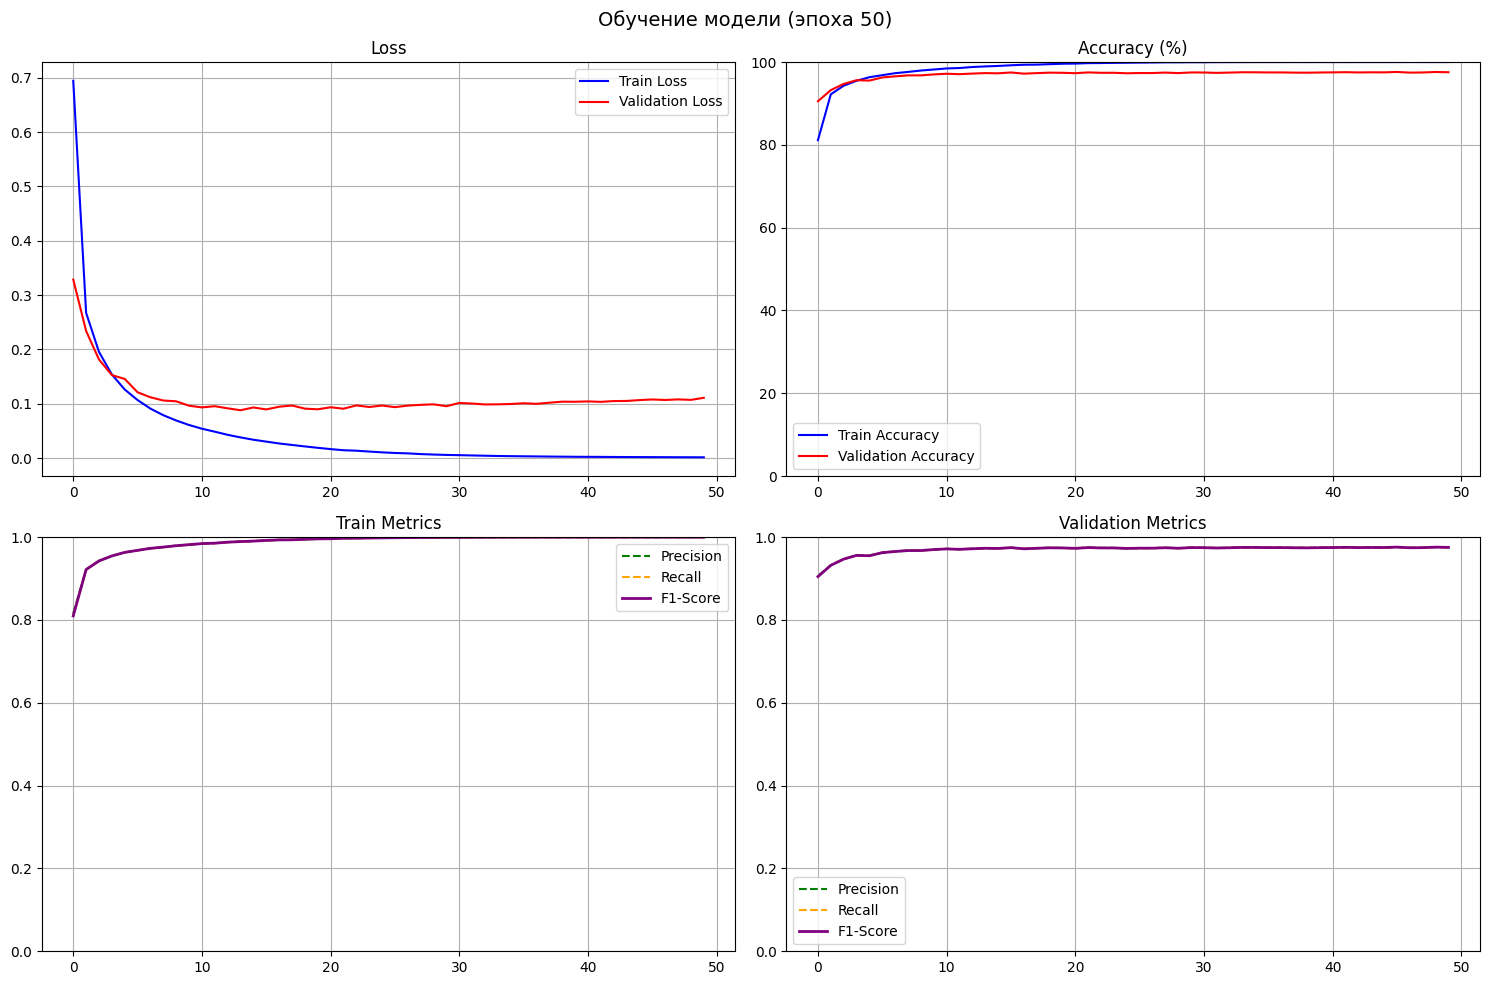

Epoch 50/50
Train - Loss: 0.0014, Acc: 100.00%, Precision: 1.000, Recall: 1.000, F1: 1.000
Val   - Loss: 0.1108, Acc: 97.53%, Precision: 0.975, Recall: 0.975, F1: 0.975

Загружена лучшая модель с валидационной ошибкой 0.0880 (эпоха 14)
Финальная оценка на тесте:
Test - Loss: 0.0857, Acc: 97.90%, Precision: 0.979, Recall: 0.979, F1: 0.979

Финальная точность Базовая: 97.90%
Обучаем модель: С Dropout


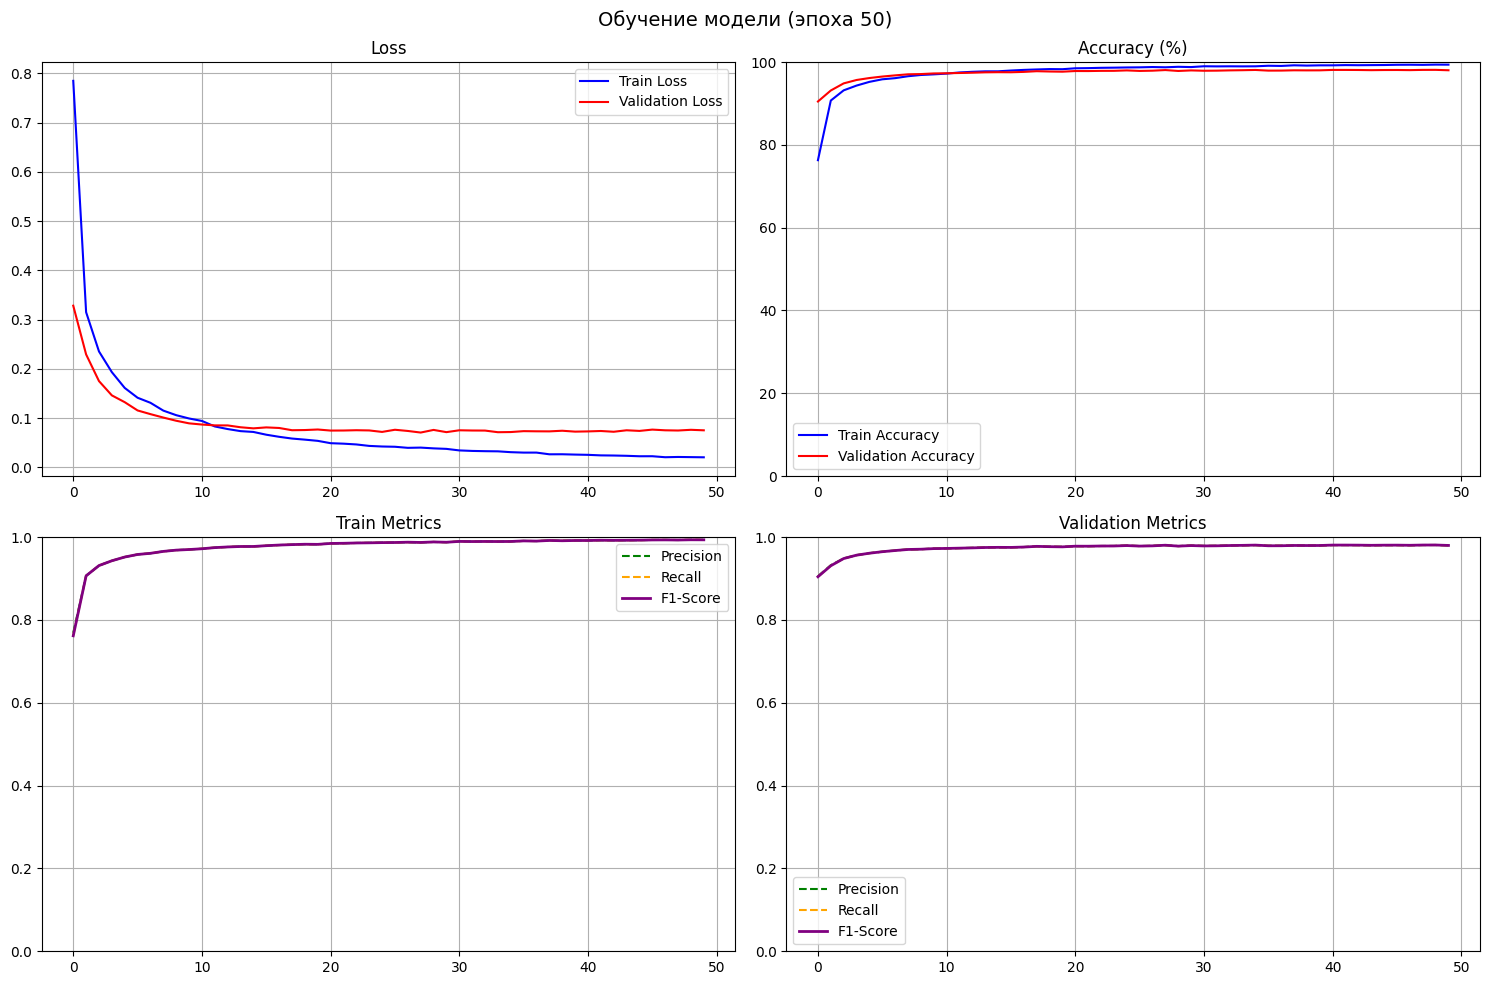

Epoch 50/50
Train - Loss: 0.0202, Acc: 99.36%, Precision: 0.994, Recall: 0.994, F1: 0.994
Val   - Loss: 0.0750, Acc: 98.01%, Precision: 0.980, Recall: 0.980, F1: 0.980

Загружена лучшая модель с валидационной ошибкой 0.0705 (эпоха 28)
Финальная оценка на тесте:
Test - Loss: 0.0677, Acc: 98.22%, Precision: 0.982, Recall: 0.982, F1: 0.982

Финальная точность С Dropout: 98.22%
Обучаем модель: С BatchNorm


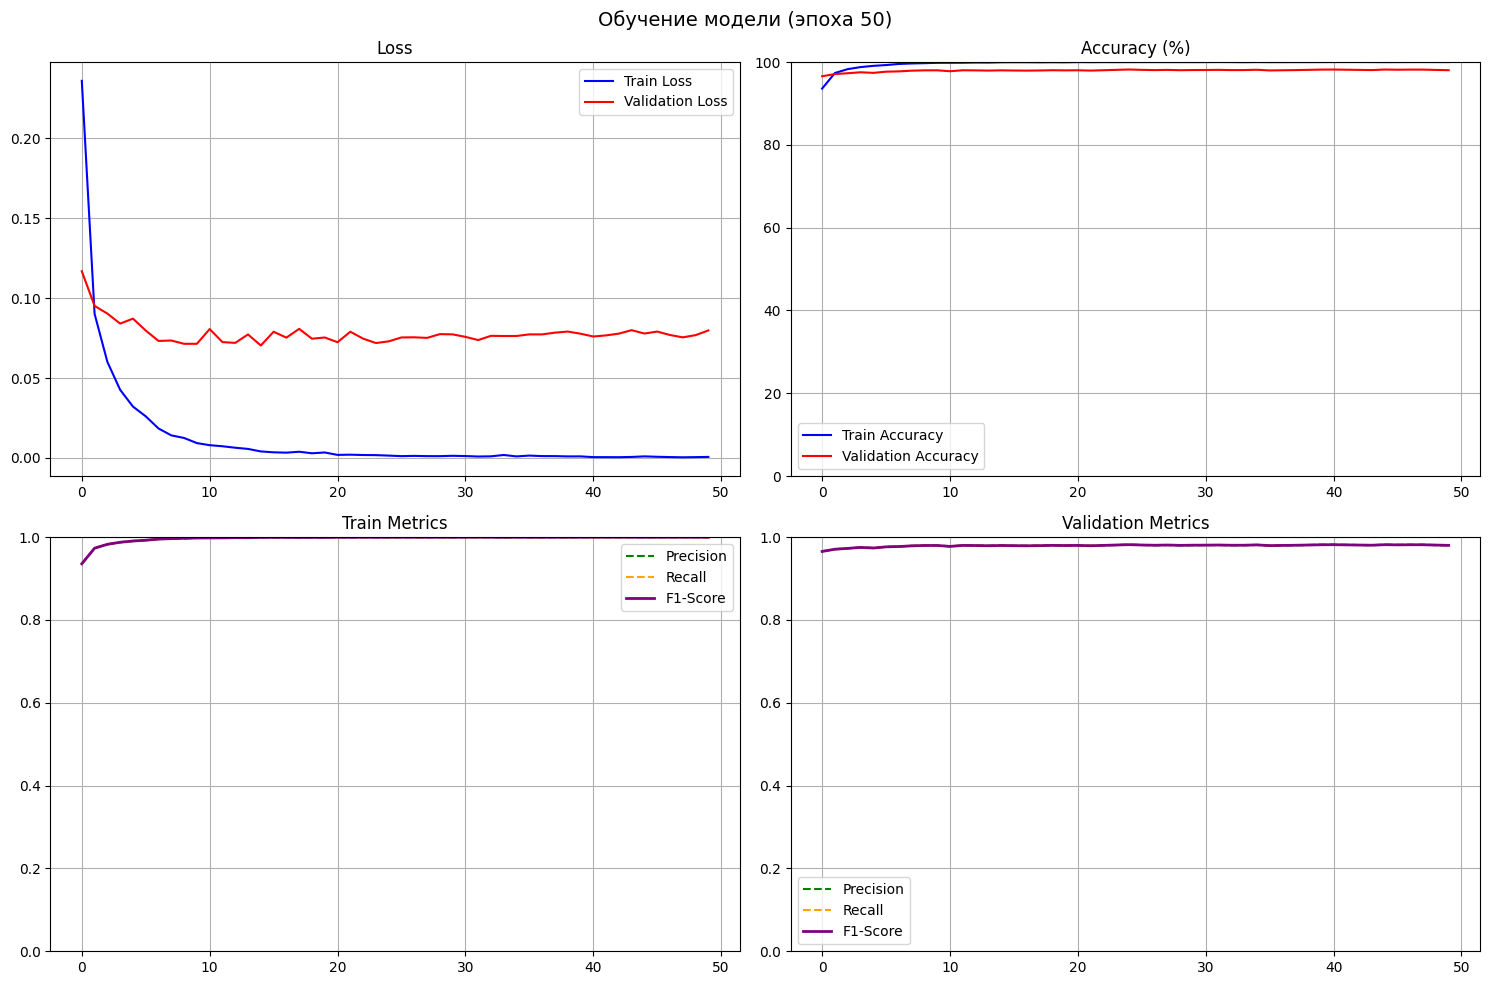

Epoch 50/50
Train - Loss: 0.0007, Acc: 99.99%, Precision: 1.000, Recall: 1.000, F1: 1.000
Val   - Loss: 0.0797, Acc: 98.02%, Precision: 0.980, Recall: 0.980, F1: 0.980

Загружена лучшая модель с валидационной ошибкой 0.0703 (эпоха 15)
Финальная оценка на тесте:
Test - Loss: 0.0723, Acc: 98.36%, Precision: 0.984, Recall: 0.984, F1: 0.984

Финальная точность С BatchNorm: 98.36%
Обучаем модель: Глубокая


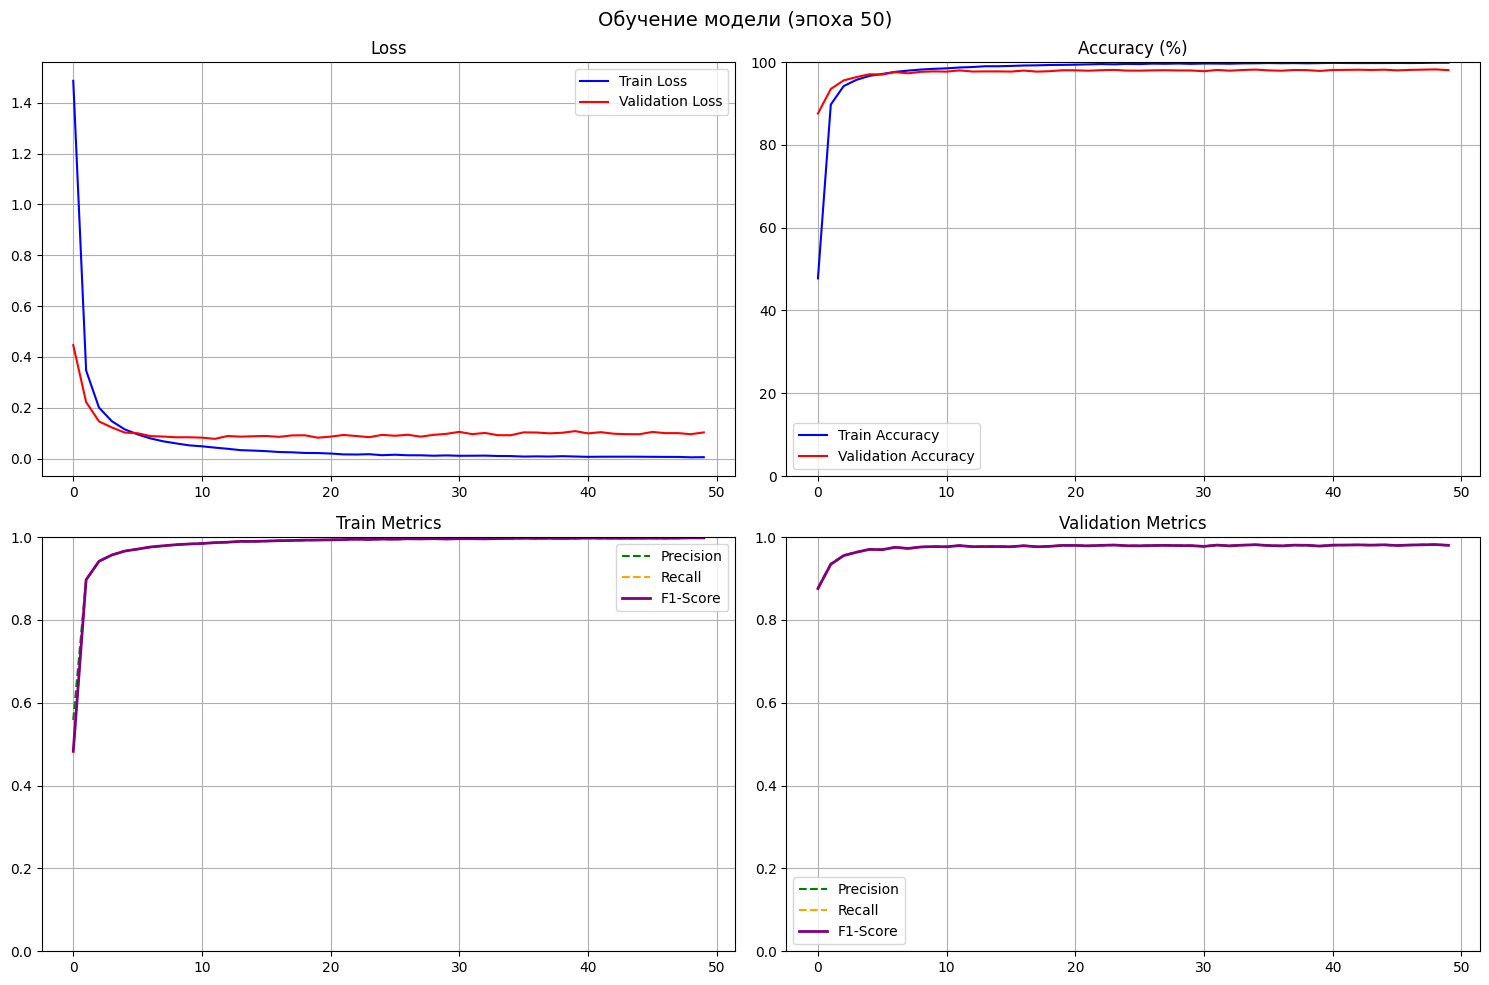

Epoch 50/50
Train - Loss: 0.0056, Acc: 99.83%, Precision: 0.998, Recall: 0.998, F1: 0.998
Val   - Loss: 0.1030, Acc: 98.03%, Precision: 0.980, Recall: 0.980, F1: 0.980

Загружена лучшая модель с валидационной ошибкой 0.0776 (эпоха 12)
Финальная оценка на тесте:
Test - Loss: 0.0949, Acc: 98.30%, Precision: 0.983, Recall: 0.983, F1: 0.983

Финальная точность Глубокая: 98.30%
Обучаем модель: С LeakyReLU


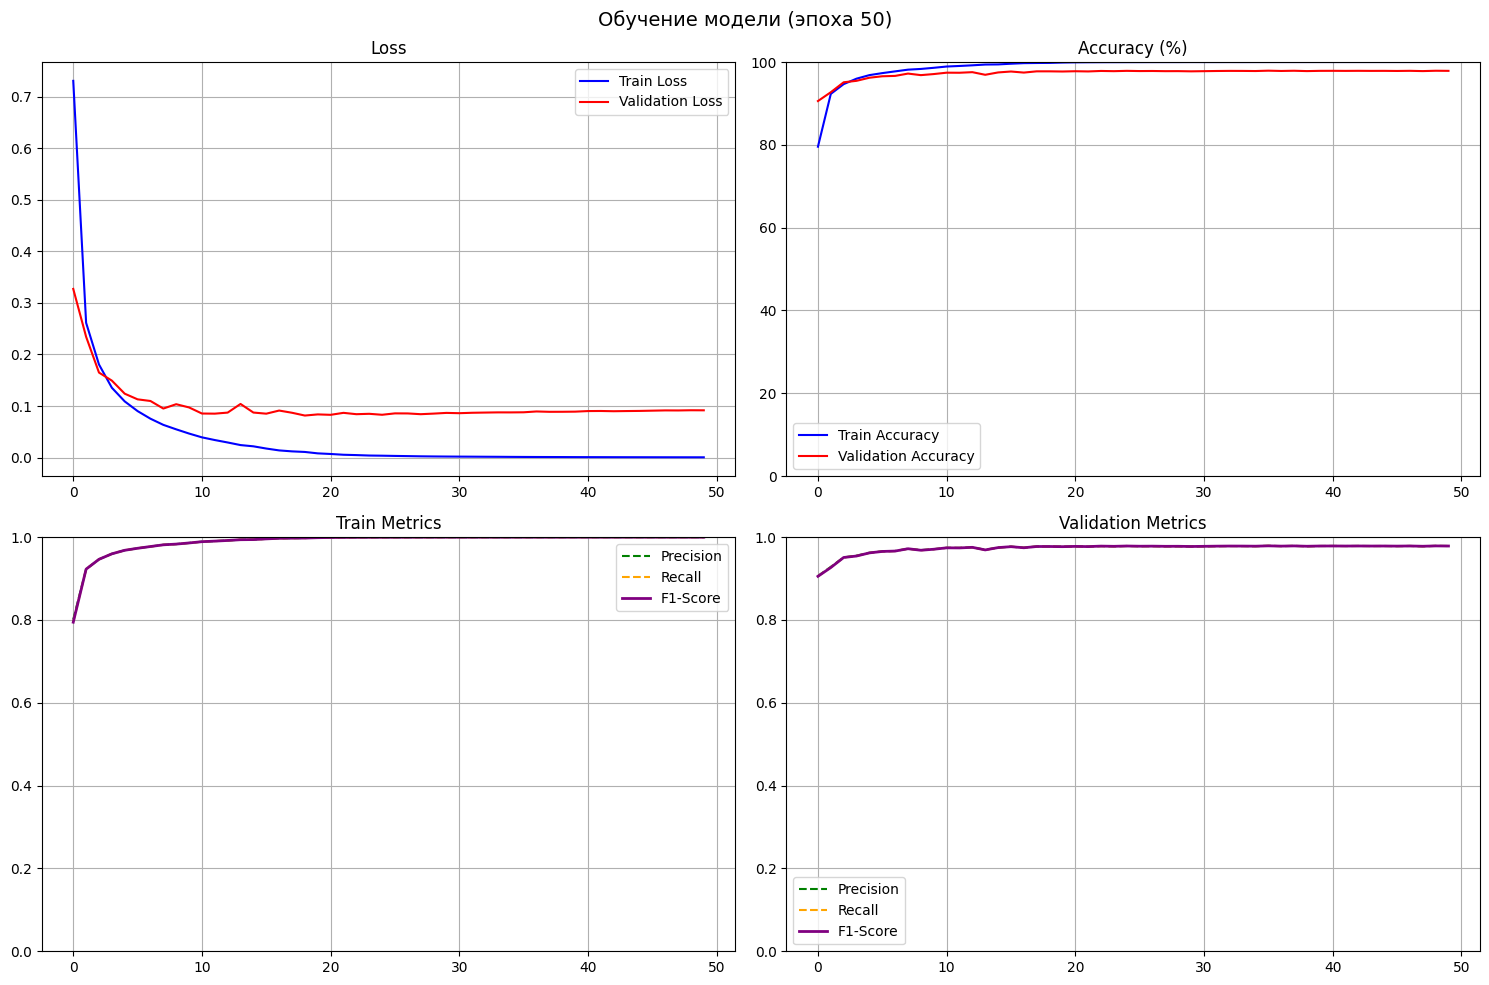

Epoch 50/50
Train - Loss: 0.0007, Acc: 100.00%, Precision: 1.000, Recall: 1.000, F1: 1.000
Val   - Loss: 0.0918, Acc: 97.87%, Precision: 0.979, Recall: 0.979, F1: 0.979

Загружена лучшая модель с валидационной ошибкой 0.0816 (эпоха 19)
Финальная оценка на тесте:
Test - Loss: 0.0830, Acc: 98.01%, Precision: 0.980, Recall: 0.980, F1: 0.980

Финальная точность С LeakyReLU: 98.01%


In [ ]:
# 5. Сравните несколько архитектур, в том числе с различным количеством слоёв и подберите оптимальную.
#    Обязательно используйте dropout и batchnorm и поясните свои выводы. Также можно попробовать различные активации в скрытых слоях.

model1 = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 10)
).to(device)

model2 = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 256),
    nn.ReLU(),
    nn.Dropout(0.3),  # 30% нейронов отключаем
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, 10)
).to(device)

model3 = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 256),
    nn.BatchNorm1d(256),  # Нормализация
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Linear(128, 10)
).to(device)

model4 = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 512),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 10)
).to(device)

model5 = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 256),
    nn.LeakyReLU(0.1),  # LeakyReLU
    nn.Linear(256, 128),
    nn.ELU(),           # ELU
    nn.Linear(128, 64),
    nn.Tanh(),          # Tanh
    nn.Linear(64, 10)
).to(device)

# Словарь для хранения результатов всех моделей
all_models_results = {}

# Список моделей для эксперимента
models_to_try = {
    'Базовая': model1,
    'С Dropout': model2,
    'С BatchNorm': model3,
    'Глубокая': model4,
    'С LeakyReLU': model5
}

# Обучаем каждую модель и сохраняем результаты
for name, model in models_to_try.items():
    optimizer = optim.SGD(model.parameters(), lr=0.1)

    print(f"Обучаем модель: {name}")
    results = train_model_function(model)
    all_models_results[name] = results
    print(f"\nФинальная точность {name}: {results['final_test_acc']:.2f}%")

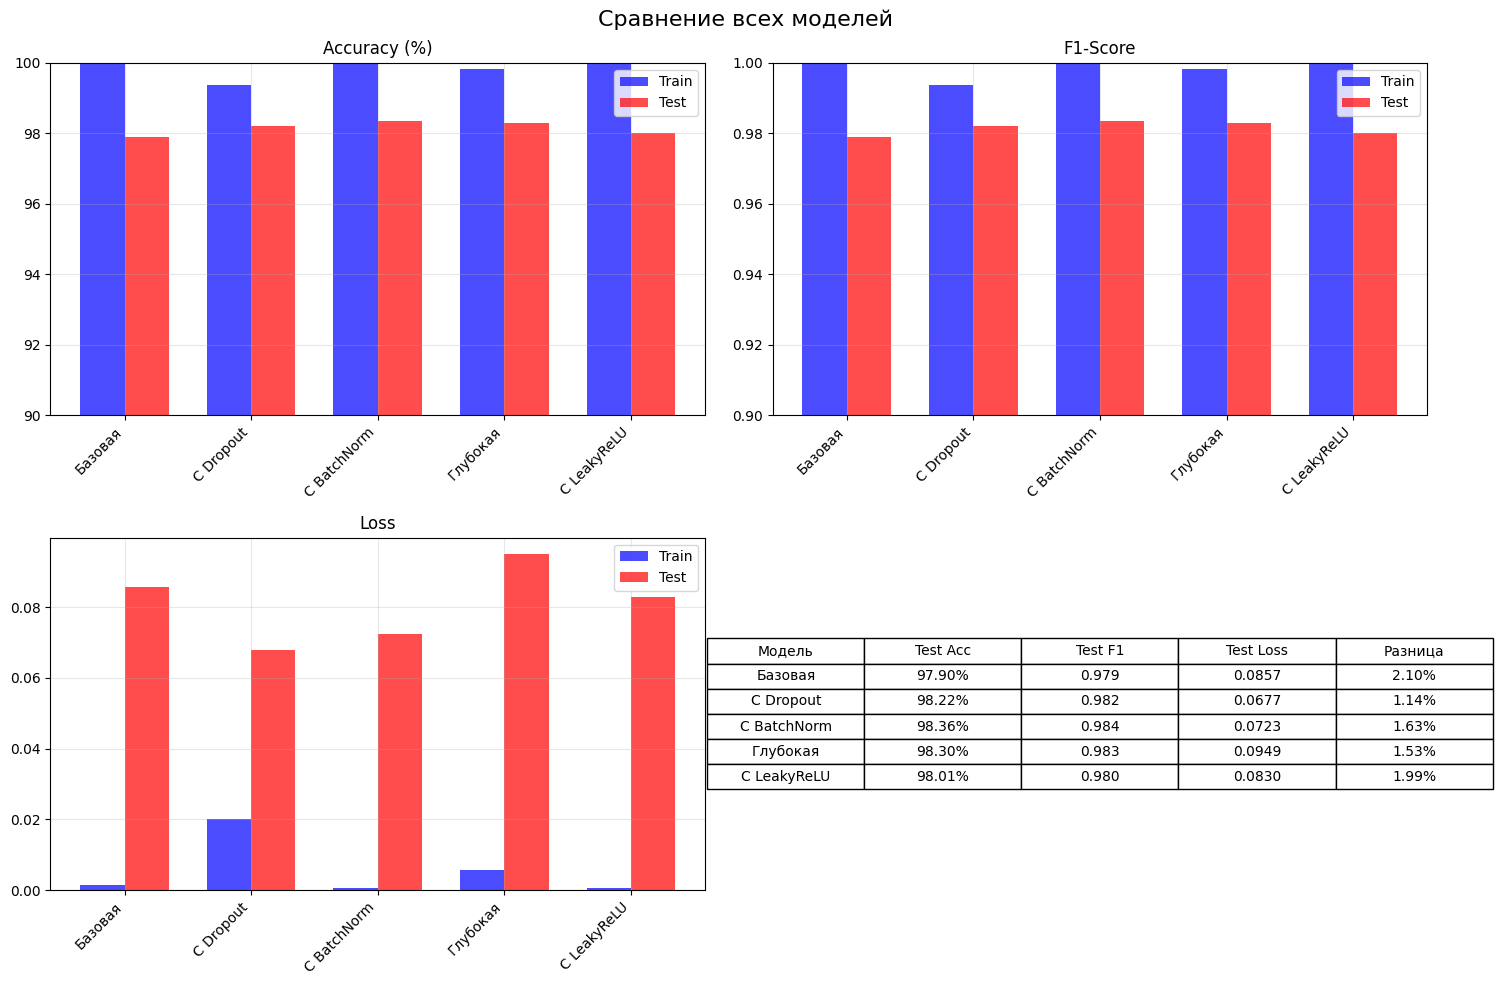


Лучшая модель: С BatchNorm
   Точность: 98.36%
   F1-Score: 0.984


In [ ]:
def plot_all_models_comparison(all_models_results):
    """
    Строит сравнительные графики для всех обученных моделей
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    names = list(all_models_results.keys())
    x = np.arange(len(names))
    width = 0.35

    # График 1: Accuracy
    ax1 = axes[0, 0]
    train_accs = [all_models_results[n]['final_train_acc'] for n in names]
    test_accs = [all_models_results[n]['final_test_acc'] for n in names]

    ax1.bar(x - width/2, train_accs, width, label='Train', color='blue', alpha=0.7)
    ax1.bar(x + width/2, test_accs, width, label='Test', color='red', alpha=0.7)
    ax1.set_title('Accuracy (%)', fontsize=12)
    ax1.set_xticks(x)
    ax1.set_xticklabels(names, rotation=45, ha='right')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim([90, 100])

    # График 2: F1-Score
    ax2 = axes[0, 1]
    train_f1s = [all_models_results[n]['final_train_f1'] for n in names]
    test_f1s = [all_models_results[n]['final_test_f1'] for n in names]

    ax2.bar(x - width/2, train_f1s, width, label='Train', color='blue', alpha=0.7)
    ax2.bar(x + width/2, test_f1s, width, label='Test', color='red', alpha=0.7)
    ax2.set_title('F1-Score', fontsize=12)
    ax2.set_xticks(x)
    ax2.set_xticklabels(names, rotation=45, ha='right')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim([0.9, 1.0])

    # График 3: Loss
    ax3 = axes[1, 0]
    train_losses = [all_models_results[n]['final_train_loss'] for n in names]
    test_losses = [all_models_results[n]['final_test_loss'] for n in names]

    ax3.bar(x - width/2, train_losses, width, label='Train', color='blue', alpha=0.7)
    ax3.bar(x + width/2, test_losses, width, label='Test', color='red', alpha=0.7)
    ax3.set_title('Loss', fontsize=12)
    ax3.set_xticks(x)
    ax3.set_xticklabels(names, rotation=45, ha='right')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # График 4: Сравнение всех финальных метрик
    ax4 = axes[1, 1]
    ax4.axis('off')  # Отключаем оси

    # Создаем таблицу с результатами
    table_data = []
    for name in names:
        res = all_models_results[name]
        table_data.append([
            name,
            f"{res['final_test_acc']:.2f}%",
            f"{res['final_test_f1']:.3f}",
            f"{res['final_test_loss']:.4f}",
            f"{res['final_train_acc'] - res['final_test_acc']:.2f}%"
        ])

    table = ax4.table(cellText=table_data,
                      colLabels=['Модель', 'Test Acc', 'Test F1', 'Test Loss', 'Разница'],
                      cellLoc='center',
                      loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.5)

    plt.suptitle('Сравнение всех моделей', fontsize=16)
    plt.tight_layout()
    plt.savefig('all_models_comparison.png', dpi=100, bbox_inches='tight')
    plt.show()

    # Находим лучшую модель
    best_model = max(names, key=lambda n: all_models_results[n]['final_test_acc'])
    print(f"\nЛучшая модель: {best_model}")
    print(f"   Точность: {all_models_results[best_model]['final_test_acc']:.2f}%")
    print(f"   F1-Score: {all_models_results[best_model]['final_test_f1']:.3f}")


plot_all_models_comparison(all_models_results)

In [ ]:
# 6. В конце напишите выводы и отчет о рассмотренных моделях.
#    Отчёт должен быть в виде таблички, в которой описан номер эксперимента,
#    минимальная ошибка на валидации, 4 классификационные метрики на тесте: аccuracy, precision, recall и f1-score,
#    к отчету должно прилагаться описание.
#    Выводы ожидаются в свободной форме и должны содержать информацию о том, почему, по вашему мнению,
#    именно эта архитектура из рассмотренных получила наилучший скор на тесте.

In [ ]:
# 6. В конце напишите выводы и отчет о рассмотренных моделях.
import pandas as pd
from IPython.display import display


report_data = []
for name, res in all_models_results.items():
    report_data.append({
        'Модель': name,
        'Min Val Loss': f"{res['min_val_loss']:.4f} (эп.{res['min_val_loss_epoch']})",
        'Test Acc (%)': f"{res['final_test_acc']:.2f}",
        'Precision': f"{res['final_test_precision']:.3f}",
        'Recall': f"{res['final_test_recall']:.3f}",
        'F1-Score': f"{res['final_test_f1']:.3f}",
        'Train-Test Gap': f"{res['final_train_acc'] - res['final_test_acc']:.2f}%"
    })

df_report = pd.DataFrame(report_data)
display(df_report)
print("\nВыводы по результатам экспериментов")

best_model = max(all_models_results.keys(),
                 key=lambda x: all_models_results[x]['final_test_acc'])
best_res = all_models_results[best_model]

print(f"\nЛучшая модель: {best_model}")
print(f"Test Accuracy: {best_res['final_test_acc']:.2f}%")
print(f"Test F1-Score: {best_res['final_test_f1']:.3f}")
print(f"Min Validation Loss: {best_res['min_val_loss']:.4f} (эпоха {best_res['min_val_loss_epoch']})")
print(f"Разница train-test: {best_res['final_train_acc'] - best_res['final_test_acc']:.2f}%")

,Модель,Min Val Loss,Test Acc (%),Precision,Recall,F1-Score,Train-Test Gap
0,Базовая,0.0880 (эп.14),97.90,0.979,0.979,0.979,2.10%
1,С Dropout,0.0705 (эп.28),98.22,0.982,0.982,0.982,1.14%
2,С BatchNorm,0.0703 (эп.15),98.36,0.984,0.984,0.984,1.63%
3,Глубокая,0.0776 (эп.12),98.30,0.983,0.983,0.983,1.53%
4,С LeakyReLU,0.0816 (эп.19),98.01,0.980,0.980,0.980,1.99%



Выводы по результатам экспериментов

Лучшая модель: С BatchNorm
Test Accuracy: 98.36%
Test F1-Score: 0.984
Min Validation Loss: 0.0703 (эпоха 15)
Разница train-test: 1.63%


Я переделала модель - добавила валидационную выборку -  и теперь победил вариант с BatchNorm. BatchNorm нормализует выходы каждого слоя, делает распределение признаков более стабильным. Модель с BatchNorm достигла минимальной ошибки на 15 эпохе, а глубокая модель без BatchNorm — на 12-й. То есть глубокая модель быстрее всё изучила и потом переучилась, тк у неё точность ниже, а с батчнорм вышла самой хорошей.







Старый вывод:
Лучший результат показала глубокая модель с четырьмя скрытыми слоями и Dropout. На мой взгляд, это произошло потому, что больше слоёв позволили модели извлекать более сложные признаки из изображений, а Dropout предотвратил переобучение. Базовая модель, несмотря на простоту, тоже справилась хорошо. Модели с BatchNorm и нестандартными активациями оказались хуже — видимо, для MNIST это избыточно. Precision, recall и f1 равны, значит классы в MNIST сбалансированы. Разрыв между train и test accuracy у лучшей модели минимальный — значит, она действительно обобщает, а не запоминает данные.